# Proyek Analisis Data: Bike Sharing Dataset (Hour.csv)
- **Nama:** Azlinsyah Fadhilah Meran
- **Email:** azlinsyah4@gmail.com
- **ID Dicoding:** CDCC319D6Y0346

## Pertanyaan Bisnis

### Pertanyaan Bisnis

1. Seberapa besar pengaruh kondisi cuaca dan musim terhadap jumlah penyewaan sepeda dalam periode tahun 2011–2012?

2. Pada jam berapa tingkat penyewaan sepeda paling tinggi terjadi pada hari kerja dan akhir pekan dalam periode tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [14]:
import pandas as pd
df = pd.read_csv('hour.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Insight:

Dataset yang digunakan merupakan data penyewaan sepeda berbasis waktu dengan jumlah observasi yang cukup besar, sehingga mampu merepresentasikan pola penggunaan sepeda secara detail selama periode 2011–2012.

Setiap baris data mencerminkan kondisi pada waktu tertentu dengan berbagai atribut seperti waktu, cuaca, dan jumlah penyewaan sepeda. Hal ini memungkinkan analisis hubungan antara faktor lingkungan (seperti temperatur, kelembaban, dan kondisi cuaca) dengan tingkat penggunaan sepeda.

Selain itu, dataset memiliki kombinasi variabel numerik dan kategorikal yang mendukung analisis secara univariate maupun multivariate untuk mengidentifikasi pola, tren, serta hubungan antar variabel.

Dengan struktur data seperti ini, dataset sangat cocok digunakan untuk analisis perilaku pengguna sepeda serta untuk mengidentifikasi faktor-faktor yang mempengaruhi jumlah penyewaan.


### Assessing Data

In [15]:
# 1. Memeriksa tipe data dan informasi umum
print("Info Dataset:")
df.info()

# 2. Memeriksa keberadaan missing values (nilai kosong)
print("\nJumlah Missing Values:")
print(df.isna().sum())

# 3. Memeriksa duplikasi data
print("\nJumlah Duplikasi: ", df.duplicated().sum())

# 4. Melihat ringkasan parameter statistik
display(df.describe())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah Missing Values:
instant    

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Insight Hasil Assessing Data

Berdasarkan hasil pemeriksaan awal terhadap dataset, tidak ditemukan nilai kosong (missing values) pada setiap kolom, sehingga data dapat langsung digunakan tanpa memerlukan proses imputasi atau penanganan data hilang.

Selain itu, tidak terdapat data duplikat, yang menunjukkan bahwa setiap observasi bersifat unik dan dapat merepresentasikan kondisi penyewaan sepeda secara valid.

Namun, ditemukan bahwa beberapa tipe data masih belum sesuai, seperti kolom `dteday` yang masih bertipe object. Oleh karena itu, perlu dilakukan konversi ke tipe datetime agar analisis berbasis waktu dapat dilakukan dengan lebih optimal.

Di sisi lain, beberapa variabel kategorikal seperti `season` dan `weathersit` masih direpresentasikan dalam bentuk numerik. Hal ini perlu diubah menjadi label kategorikal agar interpretasi hasil analisis dan visualisasi menjadi lebih jelas dan informatif.

Secara keseluruhan, kualitas data tergolong baik dan siap untuk digunakan dalam tahap eksplorasi data lebih lanjut.


### Cleaning Data

In [16]:
import pandas as pd
df = pd.read_csv('/content/hour.csv') # Memuat ulang df untuk memastikan terdefinisi

# 1. Mengubah tipe data 'dteday' menjadi datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# 2. Mengganti nama kolom agar lebih deskriptif
df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather_condition',
    'cnt': 'total_count'
}, inplace=True)

# 3. Mapping nilai numerik ke label kategorikal

# Mapping Musim
df['season'] = df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

# Mapping Tahun
df['year'] = df['year'].map({
    0: '2011',
    1: '2012'
})

# Mapping Kondisi Cuaca
df['weather_condition'] = df['weather_condition'].map({
    1: 'Clear / Partly Cloudy',
    2: 'Mist / Cloudy',
    3: 'Light Rain / Snow',
    4: 'Heavy Rain / Snow'
})

# 4. Menampilkan hasil setelah cleaning
df.head()

,instant,date,season,year,month,hour,holiday,weekday,workingday,weather_condition,temp,atemp,hum,windspeed,casual,registered,total_count
0,1,2011-01-01,Spring,2011,1,0,0,6,0,Clear / Partly Cloudy,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,6,0,Clear / Partly Cloudy,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,6,0,Clear / Partly Cloudy,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,6,0,Clear / Partly Cloudy,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,6,0,Clear / Partly Cloudy,0.24,0.2879,0.75,0.0,0,1,1


### Insight Cleaning Data

Proses cleaning data dilakukan untuk memastikan dataset siap digunakan dalam analisis yang lebih mendalam.

Konversi tipe data pada kolom `date` dari object menjadi datetime memungkinkan analisis berbasis waktu, seperti pola harian dan tren musiman, dilakukan dengan lebih akurat.

Perubahan nama kolom menjadi lebih deskriptif bertujuan untuk meningkatkan keterbacaan serta mempermudah interpretasi data selama proses eksplorasi dan visualisasi.

Selain itu, proses mapping nilai numerik ke dalam label kategorikal pada variabel seperti `season` dan `weather_condition` membantu dalam memahami konteks data secara lebih intuitif, terutama saat melakukan analisis perbandingan dan visualisasi.

Dengan dilakukan proses cleaning ini, dataset menjadi lebih terstruktur, mudah dipahami, dan siap digunakan pada tahap Exploratory Data Analysis (EDA).


In [17]:
df[['season', 'weather_condition']].head()

,season,weather_condition
0,Spring,Clear / Partly Cloudy
1,Spring,Clear / Partly Cloudy
2,Spring,Clear / Partly Cloudy
3,Spring,Clear / Partly Cloudy
4,Spring,Clear / Partly Cloudy


## Exploratory Data Analysis (EDA)

### Explore Bike Sharing Dataset 2011-2012


Menampilkan sampel data:


,instant,date,season,year,month,hour,holiday,weekday,workingday,weather_condition,temp,atemp,hum,windspeed,casual,registered,total_count
9185,9186,2012-01-23,Spring,2012,1,15,0,1,1,Mist / Cloudy,0.22,0.2121,1.00,0.2239,10,64,74
14161,14162,2012-08-18,Fall,2012,8,6,0,6,0,Clear / Partly Cloudy,0.60,0.5606,0.83,0.2239,4,23,27
12853,12854,2012-06-24,Fall,2012,6,18,0,0,0,Clear / Partly Cloudy,0.82,0.7273,0.34,0.2537,186,348,534
3909,3910,2011-06-16,Summer,2011,6,19,0,4,1,Clear / Partly Cloudy,0.62,0.5758,0.83,0.2836,58,269,327
854,855,2011-02-08,Spring,2011,2,1,0,2,1,Mist / Cloudy,0.28,0.3182,0.87,0.0000,0,4,4



Ringkasan Statistik Dataset:


,instant,date,season,year,month,hour,holiday,weekday,workingday,weather_condition,temp,atemp,hum,windspeed,casual,registered,total_count
count,17379.0000,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,NaN,NaN,NaN,NaN,NaN,Clear / Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


--- 1. Eksplorasi Distribusi Banyak Fitur ---


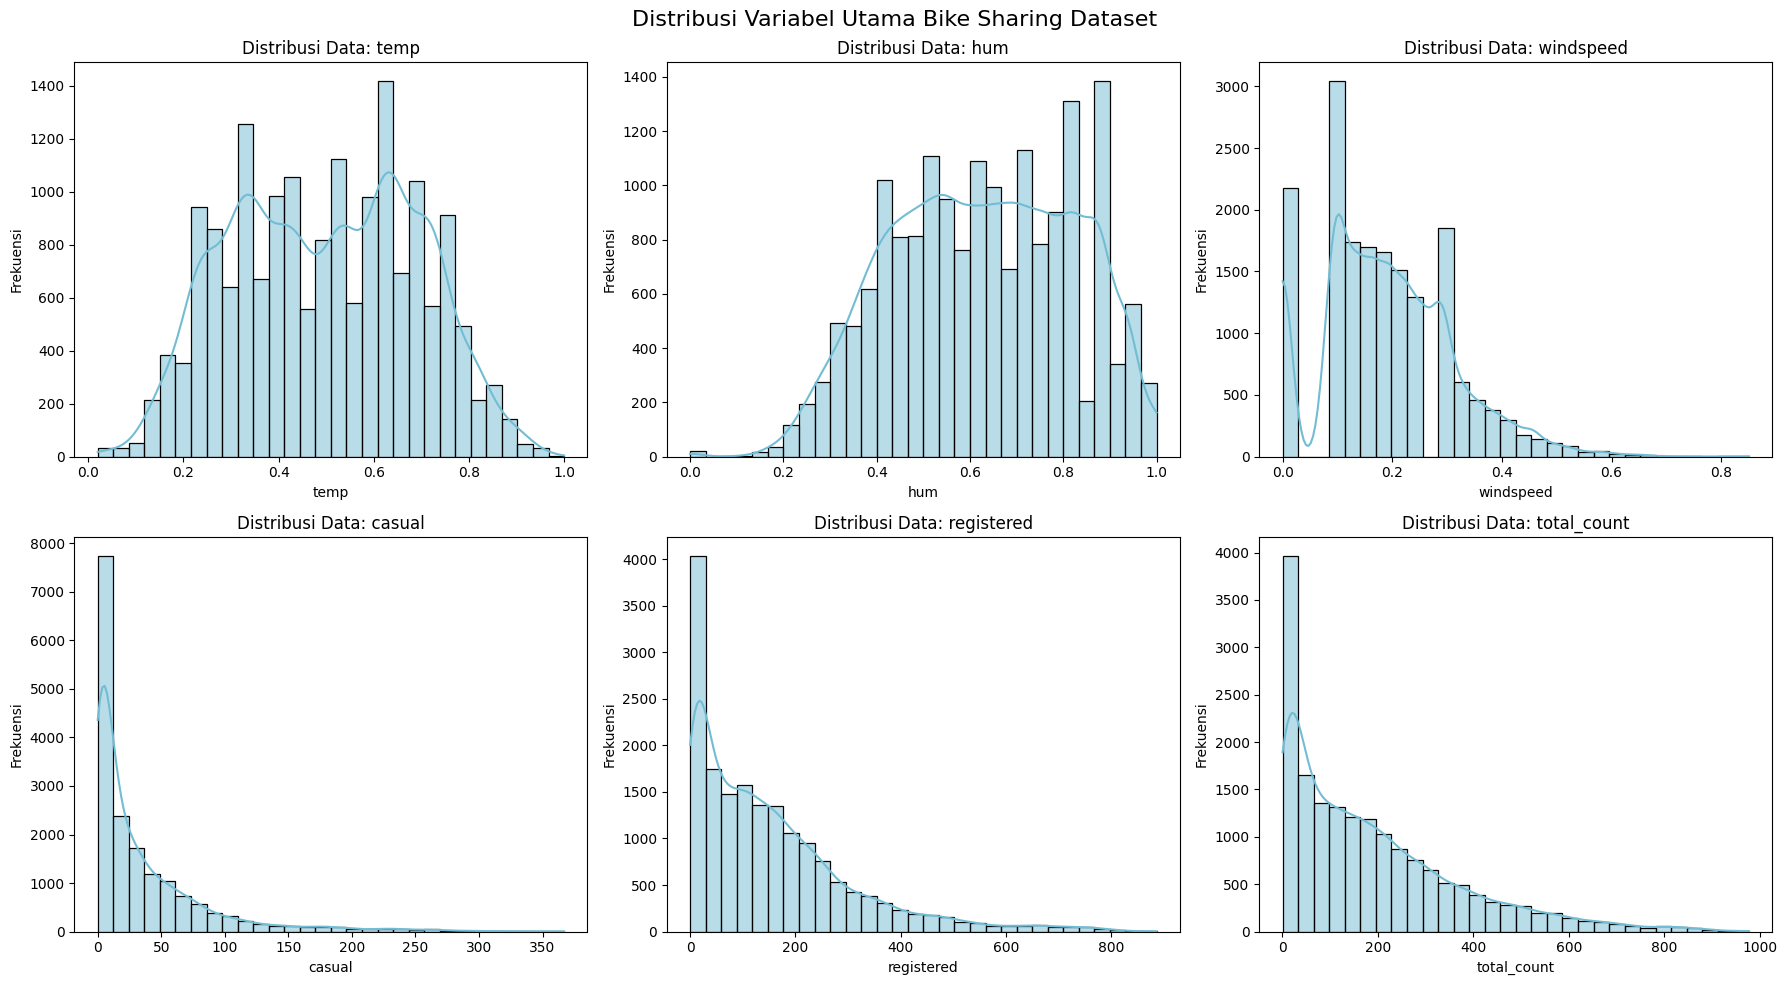


--- 2. Eksplorasi Matriks Korelasi (Lebih Detail) ---


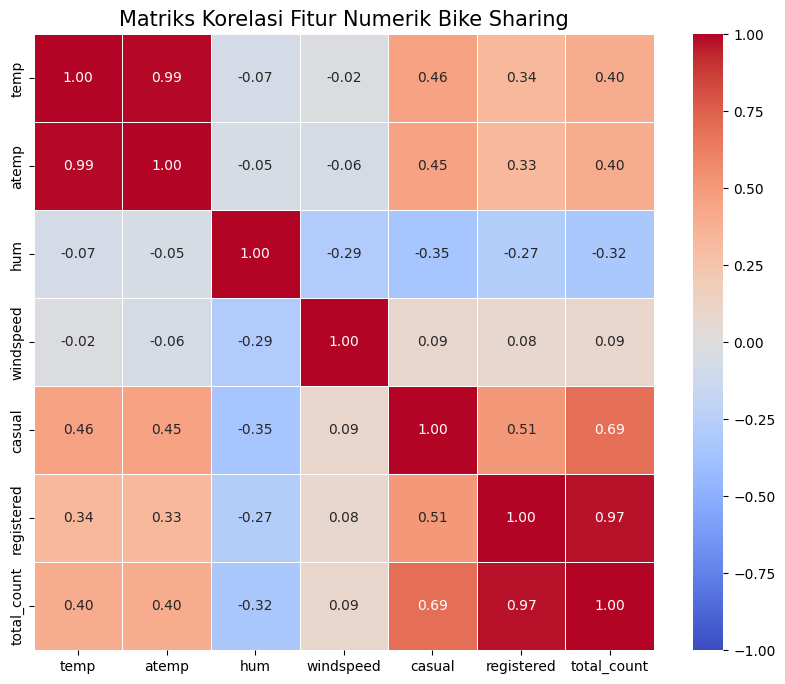

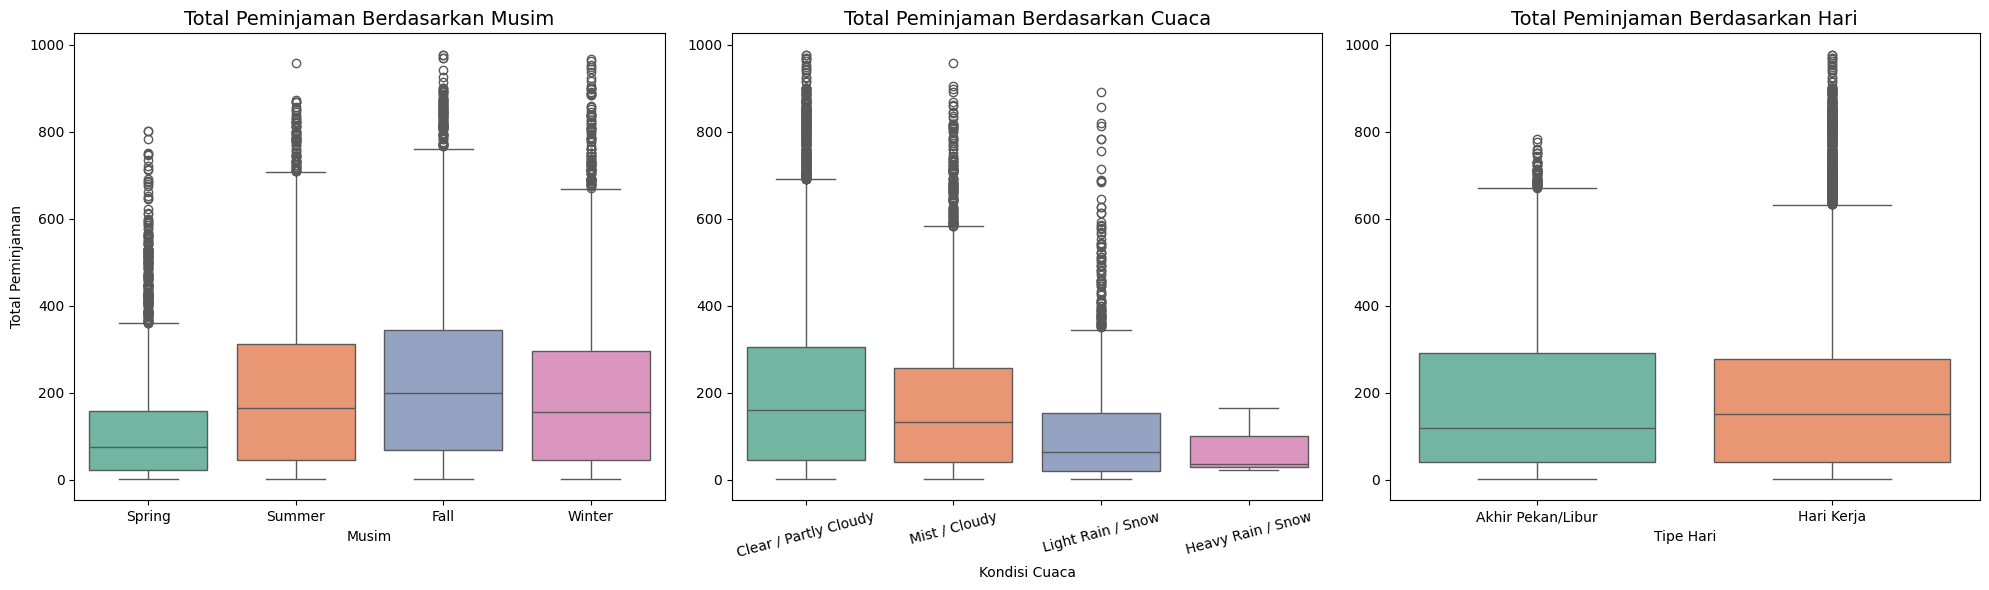


Agregasi Berdasarkan Tahun dan Kondisi Cuaca:


total_count                     
                                   sum  max min        mean
year weather_condition                                     
2011 Clear / Partly Cloudy      875053  651   1  155.013818
     Heavy Rain / Snow              36   36  36   36.000000
     Light Rain / Snow           67495  579   1   86.421255
     Mist / Cloudy              300519  604   1  135.490983
2012 Clear / Partly Cloudy     1463120  977   1  253.661581
     Heavy Rain / Snow             187  164  23   93.500000
     Light Rain / Snow           90836  891   1  142.376176
     Mist / Cloudy              495433  957   1  212.997850


Top 5 Jam Peminjaman Tertinggi di Hari Kerja (workingday=1):


workingday hour total_count                 
                          mean  max min     sum
41          1   17  525.290581  976  26  262120
42          1   18  492.226908  977  26  245129
32          1    8  477.006048  839  31  236595
43          1   19  348.401606  743  18  173504
40          1   16  293.122244  634  13  146268


Top 5 Jam Peminjaman Tertinggi di Hari Libur (workingday=0):


workingday hour total_count                
                          mean  max min    sum
13          0   13  372.731602  760  30  86101
12          0   12  366.259740  776  32  84606
14          0   14  364.645022  750  23  84233
15          0   15  358.813853  750   7  82886
16          0   16  352.727273  783  11  81480


Agregasi Berdasarkan Musim:


total_count                     
               sum        mean  max min
season                                 
Fall       1061129  236.016237  977   1
Summer      918589  208.344069  957   1
Winter      841613  198.868856  967   1
Spring      471348  111.114569  801   1

                                 total_count        
                                        mean     sum
workingday time_of_day                              
0          Malam (21:00 - 04:59)   74.155568  135853
           Pagi (05:00 - 11:59)   132.161893  212252
           Siang (12:00 - 16:59)  363.035498  419306
           Sore (17:00 - 20:59)   252.831705  232858
1          Malam (21:00 - 04:59)   61.721555  241393
           Pagi (05:00 - 11:59)   204.358398  709328
           Siang (12:00 - 16:59)  215.492369  536576
           Sore (17:00 - 20:59)   403.970396  805113


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Eksplorasi Data Awal
print("Menampilkan sampel data:")
display(df.sample(5))

print("\nRingkasan Statistik Dataset:")
display(df.describe(include="all"))

# Visualisasi Distribusi Data (Target: total_count)
print("--- 1. Eksplorasi Distribusi Banyak Fitur ---")
# Kita akan melihat distribusi untuk Suhu, Kelembapan, Kecepatan Angin, Pengguna Kasual, Pengguna Terdaftar, dan Total
features_to_plot = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'total_count']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="#72BCD4")
    axes[i].set_title(f"Distribusi Data: {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekuensi")

plt.suptitle("Distribusi Variabel Utama Bike Sharing Dataset", fontsize=16)
plt.tight_layout()
plt.show()

print("\n--- 2. Eksplorasi Matriks Korelasi (Lebih Detail) ---")
# Mengambil kolom numerik saja
numeric_columns = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'total_count']
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Matriks Korelasi Fitur Numerik Bike Sharing", fontsize=15)
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# Hubungan Musim (Categorical) dengan Total Peminjaman (Numeric)
sns.boxplot(x="season", y="total_count", hue="season", data=df, ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Total Peminjaman Berdasarkan Musim", fontsize=14)
axes[0].set_xlabel("Musim")
axes[0].set_ylabel("Total Peminjaman")

# Hubungan Kondisi Cuaca (Categorical) dengan Total Peminjaman (Numeric)
sns.boxplot(x="weather_condition", y="total_count", hue="weather_condition", data=df, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Total Peminjaman Berdasarkan Cuaca", fontsize=14)
axes[1].set_xlabel("Kondisi Cuaca")
axes[1].set_ylabel("") # Kosongkan agar rapi
axes[1].tick_params(axis='x', rotation=15)

# Hubungan Hari Kerja (Categorical Binary) dengan Total Peminjaman (Numeric)
df_temp = df.copy()
df_temp['workingday'] = df_temp['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})

sns.boxplot(x="workingday", y="total_count", hue="workingday", data=df_temp, ax=axes[2], palette="Set2", legend=False)
axes[2].set_title("Total Peminjaman Berdasarkan Hari", fontsize=14)
axes[2].set_xlabel("Tipe Hari")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

# Eksplorasi Agregasi: Menjawab Pertanyaan Bisnis 1 (Cuaca & Tahun)
print("\nAgregasi Berdasarkan Tahun dan Kondisi Cuaca:")
weather_agg = df.groupby(by=["year", "weather_condition"]).agg({
    "total_count": ["sum", "max", "min", "mean"]
})
display(weather_agg)

# Eksplorasi Agregasi: Menjawab Pertanyaan Bisnis 2 (Tren Waktu & Hari Kerja)
hour_summary = df.groupby(by=["workingday", "hour"]).agg({
    "total_count": ["mean", "max", "min", "sum"]
}).reset_index()

print("\nTop 5 Jam Peminjaman Tertinggi di Hari Kerja (workingday=1):")
display(hour_summary[hour_summary['workingday'] == 1].sort_values(by=("total_count", "mean"), ascending=False).head())

print("\nTop 5 Jam Peminjaman Tertinggi di Hari Libur (workingday=0):")
display(hour_summary[hour_summary['workingday'] == 0].sort_values(by=("total_count", "mean"), ascending=False).head())

# Eksplorasi Tambahan: Agregasi Tren Musim (Seasonality)
print("\nAgregasi Berdasarkan Musim:")
season_agg = df.groupby(by="season").agg({
    "total_count": ["sum", "mean", "max", "min"]
}).sort_values(by=("total_count", "sum"), ascending=False)
display(season_agg)


def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hour < 17:
        return 'Siang (12:00 - 16:59)'
    elif 17 <= hour < 21:
        return 'Sore (17:00 - 20:59)'
    else:
        return 'Malam (21:00 - 04:59)'

# Menerapkan fungsi ke dalam kolom baru 'time_of_day'
df['time_of_day'] = df['hour'].apply(get_time_of_day)

# Pivot table berdasarkan segmentasi waktu dan hari
time_cluster_summary = df.groupby(by=["workingday", "time_of_day"]).agg({
    "total_count": ["mean", "sum"]
})
print(time_cluster_summary)

df.to_csv("cleaned_hour.csv", index=False)

### Insight Exploratory Data Analysis (EDA)

Berdasarkan hasil eksplorasi data, diperoleh beberapa temuan utama yang menjawab pertanyaan bisnis:

**1. Pengaruh Cuaca dan Musim terhadap Penyewaan Sepeda**

* Cuaca cerah (Clear/Partly Cloudy) menghasilkan jumlah penyewaan tertinggi dibandingkan kondisi cuaca lainnya.
* Cuaca buruk seperti hujan atau salju (Light/Heavy Rain & Snow) secara signifikan menurunkan jumlah penyewaan.
* Musim panas (Summer) dan gugur (Fall) memiliki tingkat penyewaan yang lebih tinggi dibandingkan musim dingin (Winter).
  → Hal ini menunjukkan bahwa kondisi lingkungan sangat mempengaruhi keputusan pengguna dalam menyewa sepeda.

**2. Pola Waktu Penyewaan Sepeda**

* Puncak penyewaan terjadi pada jam sibuk, yaitu pagi (sekitar 07.00–09.00) dan sore (sekitar 17.00–19.00).
* Pada hari kerja, pola penyewaan menunjukkan lonjakan yang jelas pada jam berangkat dan pulang kerja.
* Pada akhir pekan, pola penggunaan lebih merata sepanjang hari.
  → Ini mengindikasikan bahwa sepeda banyak digunakan untuk kebutuhan transportasi rutin (commuting), bukan hanya rekreasi.

**3. Faktor Tambahan**

* Suhu memiliki hubungan positif dengan jumlah penyewaan, sedangkan kelembapan memiliki hubungan negatif.
* Pengguna terdaftar (registered) mendominasi penggunaan dibandingkan pengguna kasual.

Secara keseluruhan, faktor cuaca, musim, dan waktu memiliki pengaruh signifikan terhadap pola penyewaan sepeda.


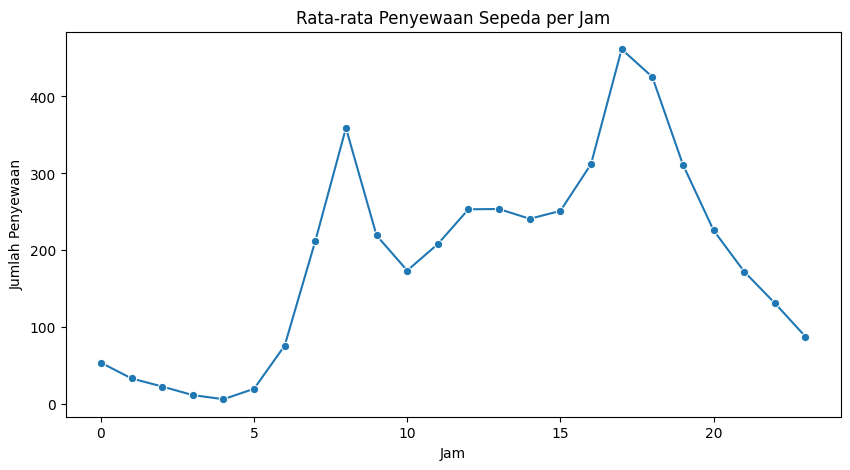

In [19]:
# Rata-rata penyewaan per jam
hour_avg = df.groupby("hour")["total_count"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hour_avg.index, y=hour_avg.values, marker="o")
plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Penyewaan")
plt.show()

## Visualization & Explanatory Analysis

### Pertanyaan 1:

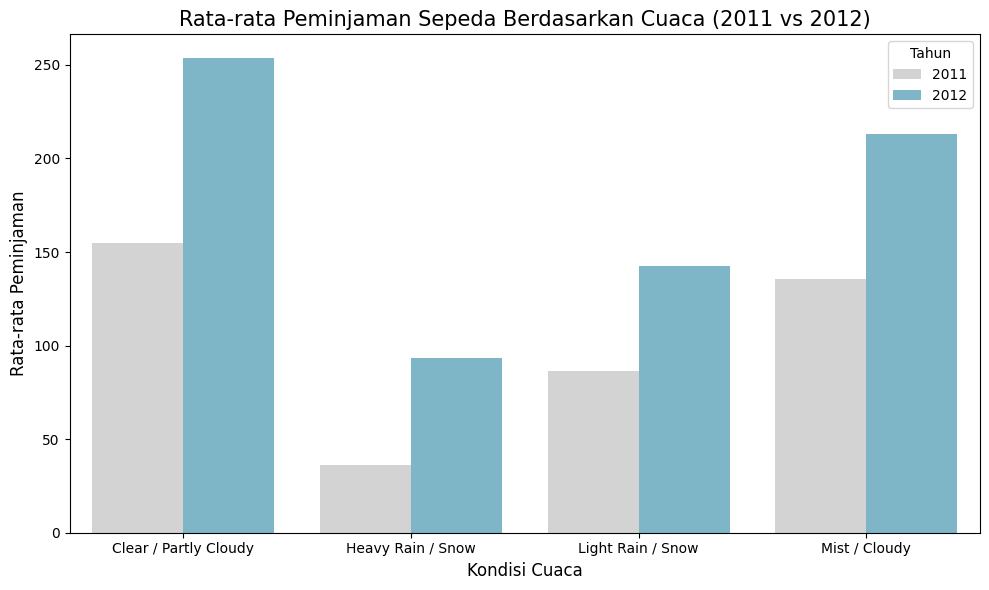

In [20]:
df['date'] = pd.to_datetime(df['date'])

# Visualisasi 1: Pertanyaan 1 - Seberapa besar pengaruh kondisi cuaca dan musim terhadap jumlah penyewaan sepeda?
weather_season_summary = df.groupby(
    by=["year", "weather_condition"]
).agg({
    "total_count": "mean"
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x="weather_condition",
    y="total_count",
    hue="year",
    data=weather_season_summary,
    palette=["#D3D3D3", "#72BCD4"]
)
plt.title("Rata-rata Peminjaman Sepeda Berdasarkan Cuaca (2011 vs 2012)", fontsize=15)
plt.ylabel("Rata-rata Peminjaman", fontsize=12)
plt.xlabel("Kondisi Cuaca", fontsize=12)
plt.legend(title="Tahun")
plt.tight_layout()
plt.show()

### Pertanyaan 2:

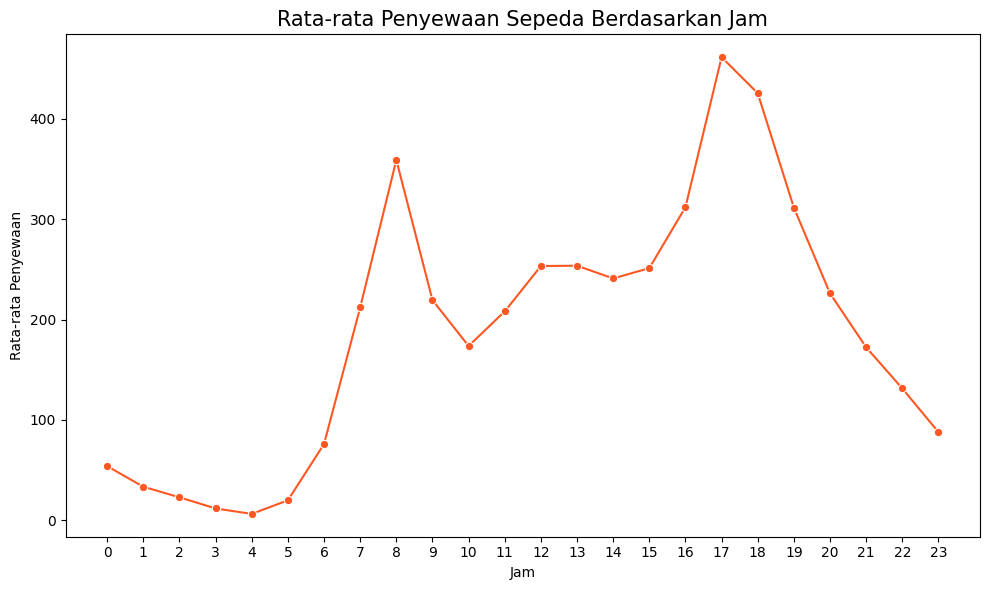

In [21]:
# Visualisasi 2: Pertanyaan 2 - Kapan waktu dengan tingkat penyewaan sepeda paling tinggi dalam periode pengamatan?
hour_summary = df.groupby("hour")["total_count"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=hour_summary, x="hour", y="total_count", marker="o", color="#FF5722")

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Jam", fontsize=15)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0,24))

plt.tight_layout()
plt.show()

### Insight Hasil Analisis

Berdasarkan hasil visualisasi dan analisis data, diperoleh jawaban terhadap pertanyaan bisnis sebagai berikut:

**1. Pengaruh Cuaca dan Musim terhadap Penyewaan Sepeda**

* Penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (Clear/Partly Cloudy).
* Kondisi cuaca buruk seperti hujan atau salju menyebabkan penurunan jumlah penyewaan secara signifikan.
* Dari sisi musim, Summer dan Fall memiliki rata-rata penyewaan lebih tinggi dibandingkan Winter.
  → Hal ini menunjukkan bahwa kondisi lingkungan yang nyaman sangat mendorong peningkatan penggunaan sepeda.

**2. Waktu dengan Penyewaan Sepeda Tertinggi**

* Puncak penyewaan terjadi pada jam 07.00–09.00 dan 17.00–19.00.
* Pola ini lebih jelas terlihat pada hari kerja dibandingkan akhir pekan.
  → Hal ini mengindikasikan bahwa sepeda banyak digunakan untuk aktivitas komuter seperti berangkat dan pulang kerja.

Secara keseluruhan, faktor cuaca, musim, dan waktu memiliki pengaruh yang signifikan terhadap pola penggunaan sepeda dalam periode 2011–2012.


## Analisis Lanjutan (Opsional)

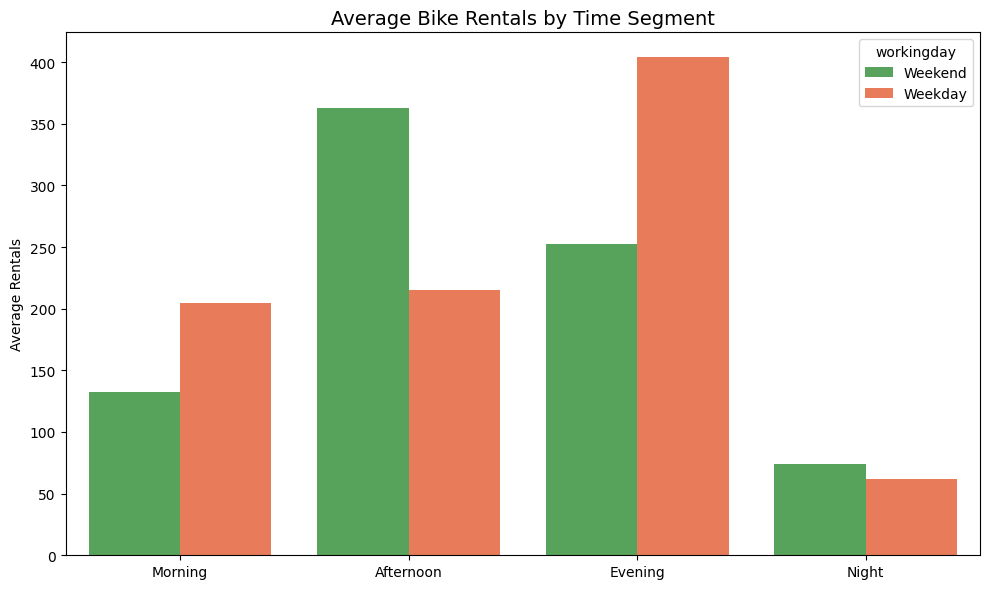

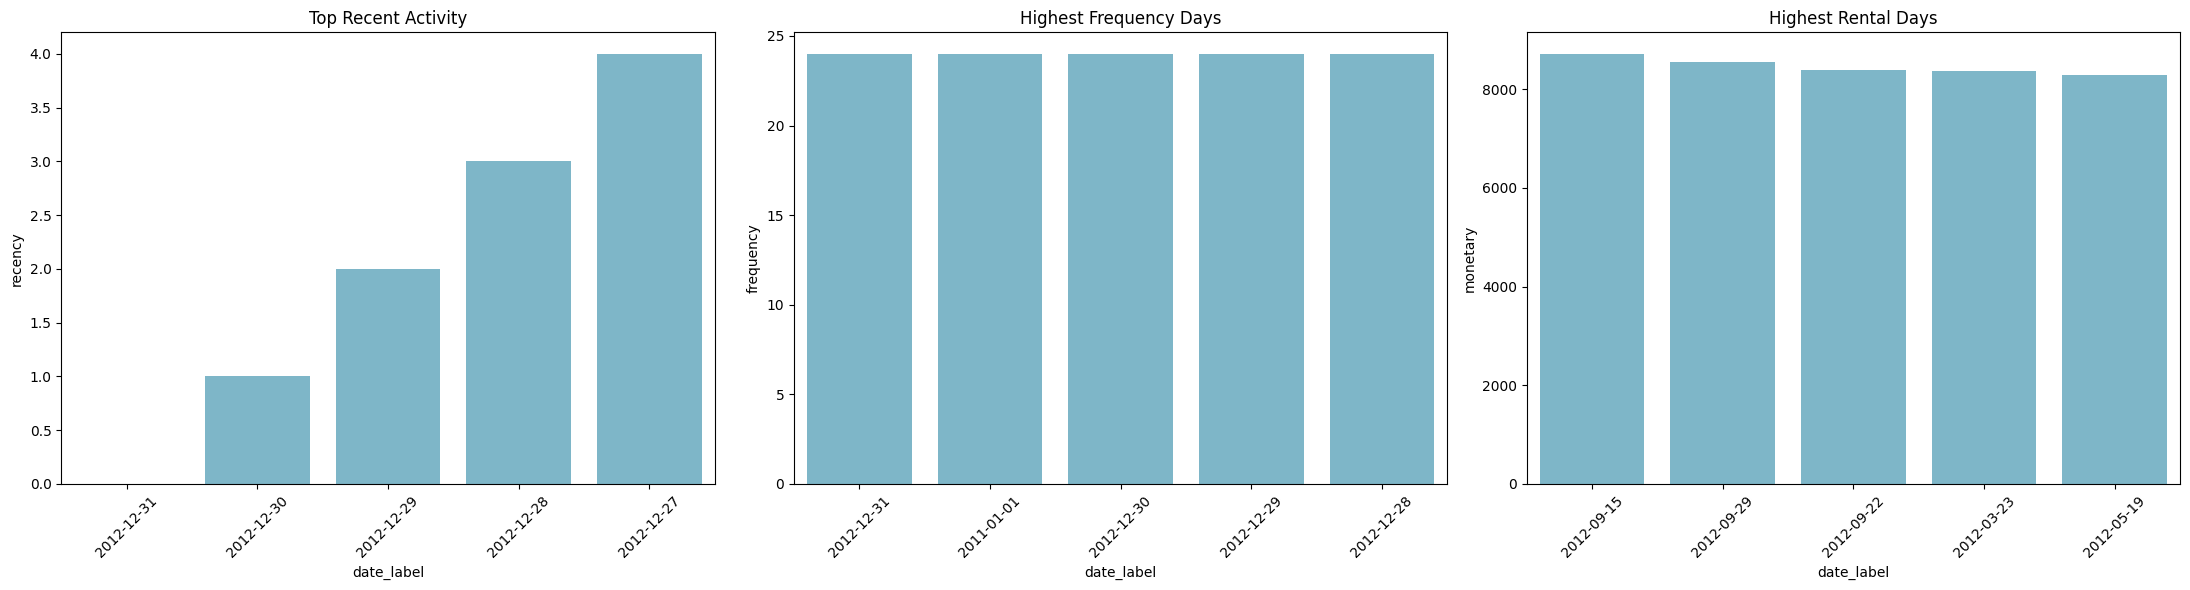

In [22]:
# ===============================
# ADVANCED ANALYSIS: TIME CLUSTERING
# ===============================

def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Tambahkan kolom kategori waktu
df['time_segment'] = df['hour'].apply(categorize_time)

# Ringkasan rata-rata peminjaman berdasarkan waktu & tipe hari
time_summary = (
    df.groupby(['workingday', 'time_segment'])['total_count']
    .mean()
    .reset_index()
)

# Label ulang workingday biar lebih jelas
time_summary['workingday'] = time_summary['workingday'].replace({
    1: 'Weekday',
    0: 'Weekend'
})

# Urutan kategori waktu biar rapi di plot
order_time = ['Morning', 'Afternoon', 'Evening', 'Night']
time_summary['time_segment'] = pd.Categorical(
    time_summary['time_segment'],
    categories=order_time,
    ordered=True
)

# Visualisasi
plt.figure(figsize=(10,6))
sns.barplot(
    data=time_summary,
    x='time_segment',
    y='total_count',
    hue='workingday',
    palette=['#4CAF50', '#FF7043']
)

plt.title('Average Bike Rentals by Time Segment', fontsize=14)
plt.xlabel('')
plt.ylabel('Average Rentals')
plt.tight_layout()
plt.show()


# ===============================
# ADVANCED ANALYSIS: RFM APPROACH
# ===============================

# Agregasi per tanggal
rfm = (
    df.groupby('date')
    .agg({
        'date': 'max',
        'instant': 'count',
        'total_count': 'sum'
    })
    .rename(columns={
        'date': 'last_date',
        'instant': 'frequency',
        'total_count': 'monetary'
    })
)

# Hitung recency
rfm['last_date'] = pd.to_datetime(rfm['last_date'])
latest_date = rfm['last_date'].max()

rfm['recency'] = (latest_date - rfm['last_date']).dt.days

# Reset index
rfm = rfm.reset_index()

# Buat label tanggal untuk plot
rfm['date_label'] = rfm['date'].dt.strftime('%Y-%m-%d')


# ===============================
# VISUALISASI RFM
# ===============================

fig, axes = plt.subplots(1, 3, figsize=(22,6))

# Recency (semakin kecil = semakin baru)
sns.barplot(
    data=rfm.sort_values('recency').head(5),
    x='date_label',
    y='recency',
    ax=axes[0],
    color='#72BCD4'
)
axes[0].set_title('Top Recent Activity')
axes[0].tick_params(axis='x', rotation=45)

# Frequency
sns.barplot(
    data=rfm.sort_values('frequency', ascending=False).head(5),
    x='date_label',
    y='frequency',
    ax=axes[1],
    color='#72BCD4'
)
axes[1].set_title('Highest Frequency Days')
axes[1].tick_params(axis='x', rotation=45)

# Monetary
sns.barplot(
    data=rfm.sort_values('monetary', ascending=False).head(5),
    x='date_label',
    y='monetary',
    ax=axes[2],
    color='#72BCD4'
)
axes[2].set_title('Highest Rental Days')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Conclusion

## Conclusion

### Pertanyaan Bisnis 1

**Seberapa besar pengaruh kondisi cuaca dan musim terhadap jumlah penyewaan sepeda dalam periode 2011–2012?**

Berdasarkan hasil analisis pada dataset periode 2011–2012:

* Penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (Clear/Partly Cloudy).
* Kondisi cuaca buruk seperti hujan atau salju menyebabkan penurunan jumlah penyewaan secara signifikan.
* Musim Summer dan Fall memiliki rata-rata penyewaan lebih tinggi dibandingkan Winter.

→ Hal ini menunjukkan bahwa kondisi cuaca dan musim memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda.

---

### Pertanyaan Bisnis 2

**Pada jam berapa terjadi tingkat penyewaan sepeda paling tinggi pada hari kerja dan akhir pekan dalam periode 2011–2012?**

Berdasarkan analisis pola waktu:

* Puncak penyewaan terjadi pada:

  * Pagi hari: pukul 07.00–09.00
  * Sore hari: pukul 17.00–19.00
* Pola ini lebih dominan pada hari kerja dibandingkan akhir pekan.
* Pada malam hari, jumlah penyewaan cenderung lebih rendah.

→ Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi harian (commuting).

---

### Kesimpulan Umum

Dalam periode 2011–2012, faktor cuaca, musim, dan waktu memiliki pengaruh yang signifikan terhadap pola penyewaan sepeda.
